# Crop Yield Prediction — Exploratory Data Analysis

This notebook explores the FAO/Kaggle crop yield dataset, which covers 101 countries, 10 crop types,
and 24 years (1990–2013). We examine the target distribution, numeric features, crop/country breakdowns,
and correlations to build intuition before cleaning and modelling.

## 1. Imports & Load Data

We import the standard data-science stack and load the raw CSV via our utility function,
which automatically drops the unnamed row-index column.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

import sys, os
sys.path.insert(0, os.path.abspath('.'))
from utils import load_data

sns.set_style('whitegrid')
%matplotlib inline

df = load_data('data/yield_df.csv')
print('Loaded shape:', df.shape)
df.head()

Loaded shape: (28242, 7)


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


## 2. Dataset Overview

We inspect the shape, data types, basic statistics, duplicate rows, and missing values to understand
the structure before any transformations.

In [2]:
print('Shape:', df.shape)
print()
print('Data types:')
print(df.dtypes)
print()
print('Describe:')
df.describe(include='all').round(2)

Shape: (28242, 7)

Data types:
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Describe:


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242,28242,28242.00,28242.00,28242.00,28242.00,28242.00
unique,101,10,NaN,NaN,NaN,NaN,NaN
top,India,Potatoes,NaN,NaN,NaN,NaN,NaN
freq,4048,4276,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2001.54,77053.33,1149.06,37076.91,20.54
std,NaN,NaN,7.05,84956.61,709.81,59958.78,6.31
min,NaN,NaN,1990.00,50.00,51.00,0.04,1.30
25%,NaN,NaN,1995.00,19919.25,593.00,1702.00,16.70
50%,NaN,NaN,2001.00,38295.00,1083.00,17529.44,21.51
75%,NaN,NaN,2008.00,104676.75,1668.00,48687.88,26.00


In [3]:
print('Duplicate rows:', df.duplicated().sum())
print()
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Unique Areas (countries):', df['Area'].nunique())
print('Unique Items (crops):', df['Item'].nunique())
print('Year range:', df['Year'].min(), '–', df['Year'].max())

Duplicate rows: 2310

Missing values per column:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Unique Areas (countries): 101
Unique Items (crops): 10
Year range: 1990 – 2013


## 3. Target Variable Distribution

`hg/ha_yield` (hectograms of crop per hectare) is our regression target. We examine its distribution
with a histogram and box plot to check for skewness and outliers before modelling.

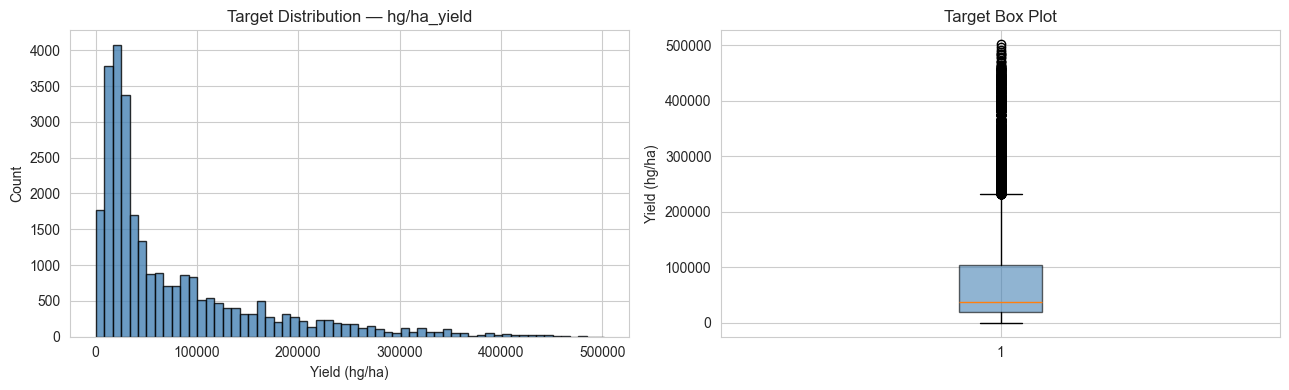

Mean yield : 77,053 hg/ha
Median     : 38,295 hg/ha
Skewness   : 1.793


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['hg/ha_yield'], bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Yield (hg/ha)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution — hg/ha_yield')

axes[1].boxplot(df['hg/ha_yield'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('Yield (hg/ha)')
axes[1].set_title('Target Box Plot')

plt.tight_layout()
plt.show()

print(f"Mean yield : {df['hg/ha_yield'].mean():,.0f} hg/ha")
print(f"Median     : {df['hg/ha_yield'].median():,.0f} hg/ha")
print(f"Skewness   : {df['hg/ha_yield'].skew():.3f}")

## 4. Univariate Analysis — Numeric Features

We look at the distribution of each numeric predictor — `average_rain_fall_mm_per_year`,
`pesticides_tonnes`, `avg_temp`, and `Year` — using histograms and box plots to spot skewness
and outliers.

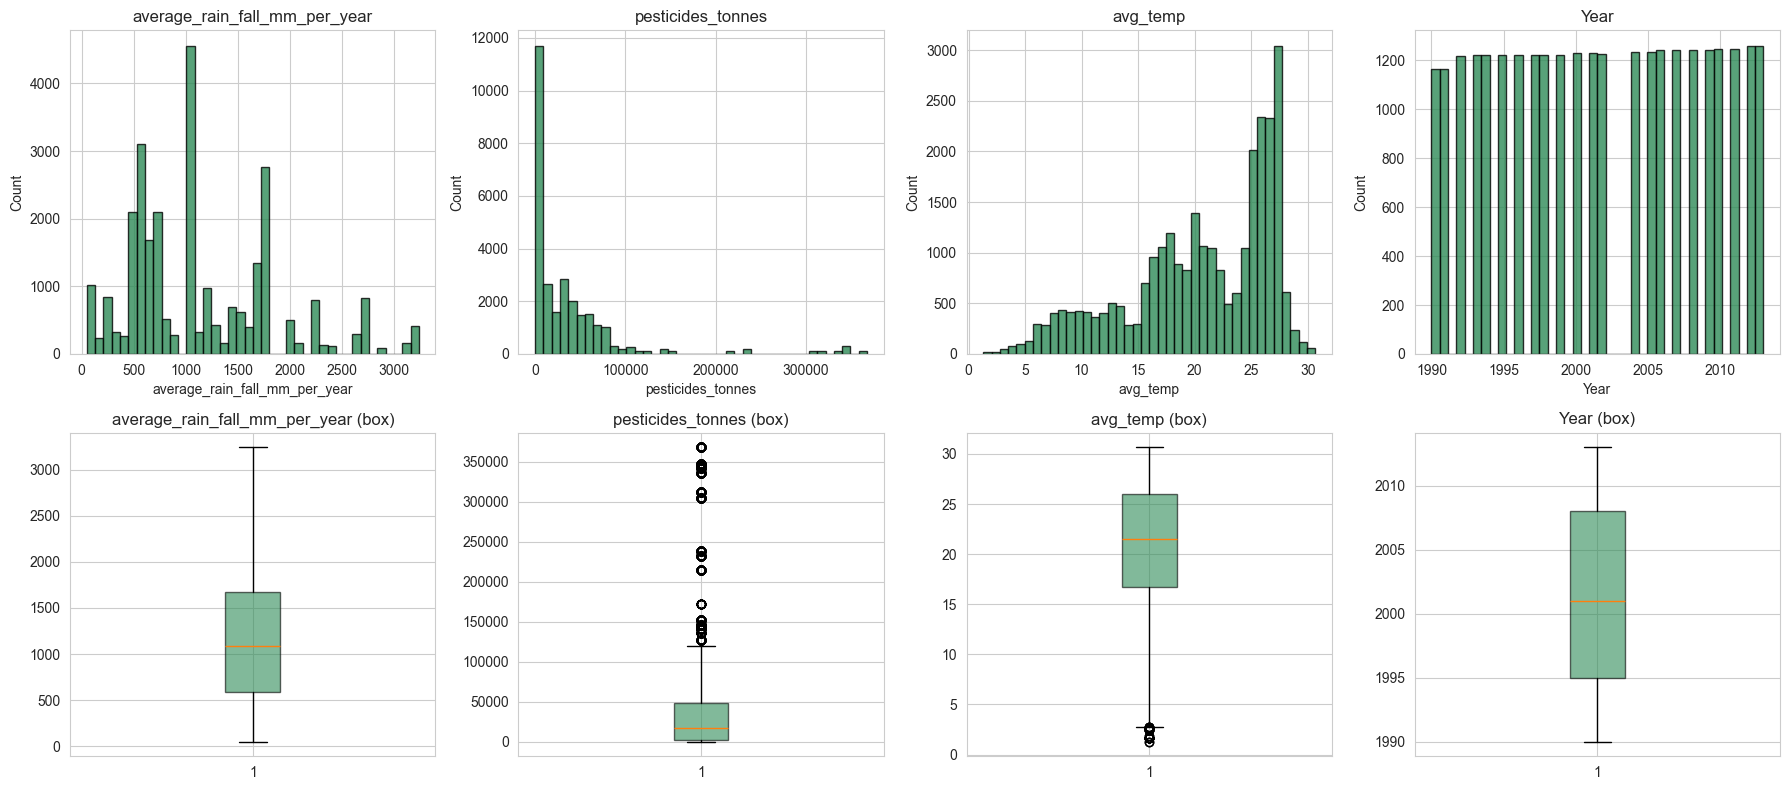

In [5]:
num_features = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Year']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_features):
    axes[0, i].hist(df[col], bins=40, color='seagreen', edgecolor='black', alpha=0.8)
    axes[0, i].set_title(f'{col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

    axes[1, i].boxplot(df[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='seagreen', alpha=0.6))
    axes[1, i].set_title(f'{col} (box)')

plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

We explore how each numeric feature relates to crop yield via scatter plots, then compare
yield distributions across the 10 crop types and identify the top-yielding countries.

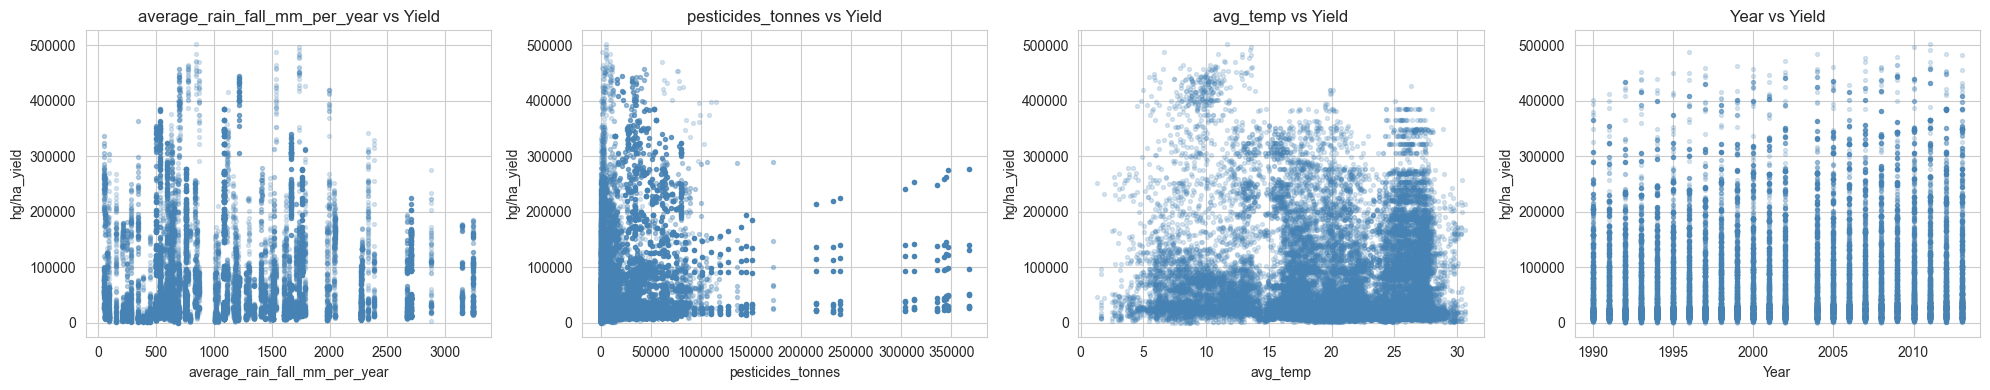

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for i, col in enumerate(num_features):
    axes[i].scatter(df[col], df['hg/ha_yield'], alpha=0.2, s=8, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('hg/ha_yield')
    axes[i].set_title(f'{col} vs Yield')
plt.tight_layout()
plt.show()

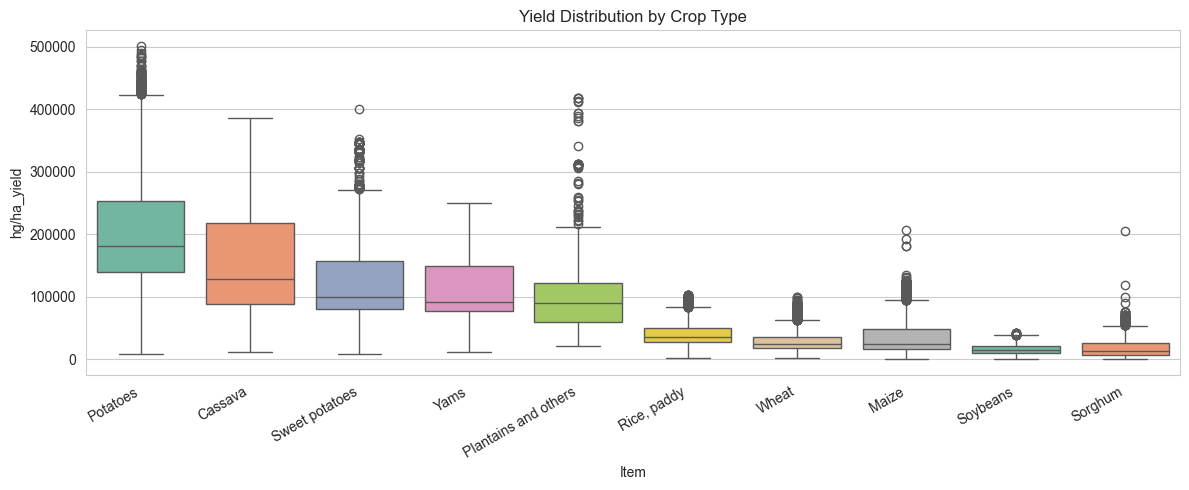

In [7]:
# Yield by crop type
plt.figure(figsize=(12, 5))
order = df.groupby('Item')['hg/ha_yield'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Item', y='hg/ha_yield', order=order, palette='Set2')
plt.xticks(rotation=30, ha='right')
plt.title('Yield Distribution by Crop Type')
plt.tight_layout()
plt.show()

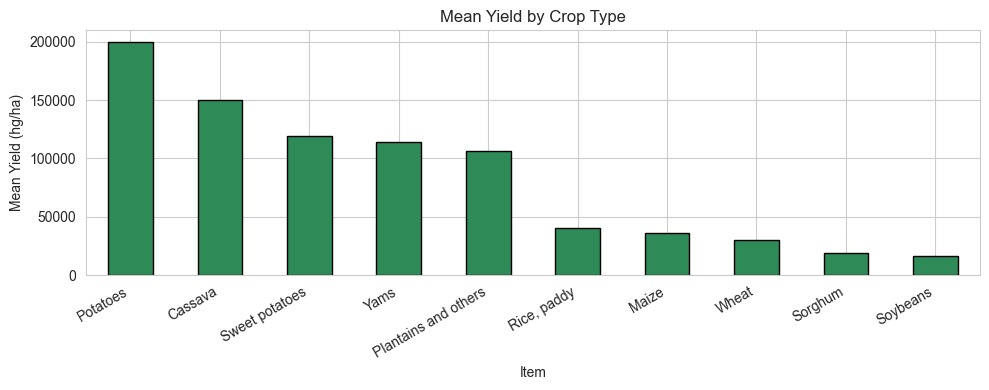

Item
Potatoes                199802.0
Cassava                 150479.0
Sweet potatoes          119058.0
Yams                    114140.0
Plantains and others    106041.0
Rice, paddy              40730.0
Maize                    36310.0
Wheat                    30116.0
Sorghum                  18636.0
Soybeans                 16731.0


In [8]:
# Mean yield per crop type (bar)
mean_by_crop = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
mean_by_crop.plot(kind='bar', color='seagreen', edgecolor='black')
plt.title('Mean Yield by Crop Type')
plt.ylabel('Mean Yield (hg/ha)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(mean_by_crop.round(0).to_string())

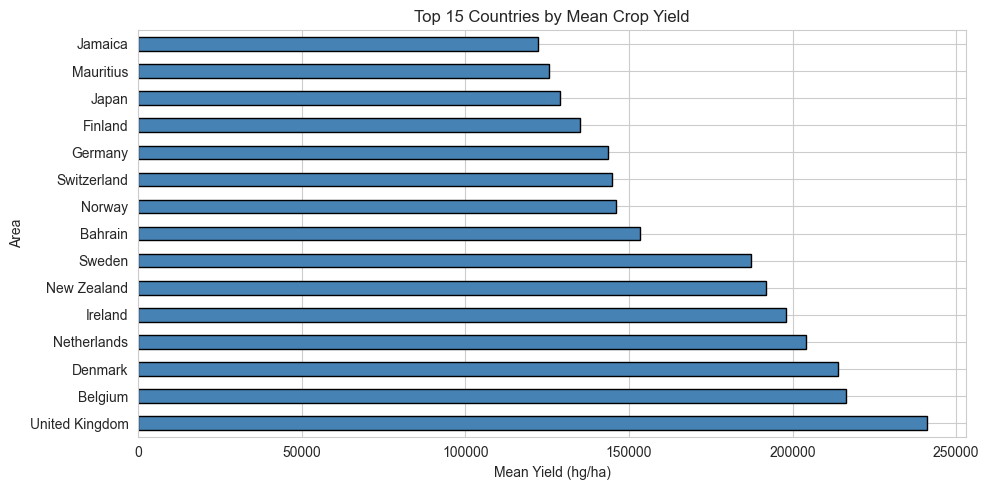

In [9]:
# Top 15 countries by mean yield
mean_by_country = df.groupby('Area')['hg/ha_yield'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 5))
mean_by_country.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Countries by Mean Crop Yield')
plt.xlabel('Mean Yield (hg/ha)')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

A heatmap of the numeric features (including the target) reveals linear relationships. Because
`Area` and `Item` are categorical, they are excluded here — their impact appears in the bivariate
section above.

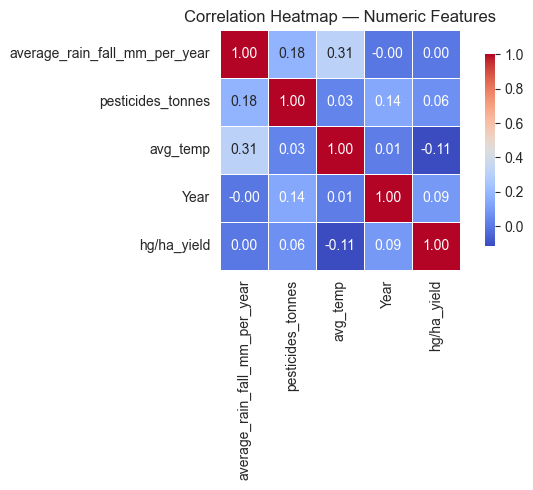


Correlations with hg/ha_yield:
Year                             0.091630
pesticides_tonnes                0.064085
average_rain_fall_mm_per_year    0.000962
avg_temp                        -0.114777
Name: hg/ha_yield, dtype: float64


In [10]:
num_df = df[['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'Year', 'hg/ha_yield']]
corr = num_df.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.show()

print('\nCorrelations with hg/ha_yield:')
print(corr['hg/ha_yield'].drop('hg/ha_yield').sort_values(ascending=False))

## 7. Domain Deep-Dive

We investigate three domain-specific questions: which crops achieve the highest maximum yields,
which countries lead per crop, and how global average yield has trended over the 24-year period.

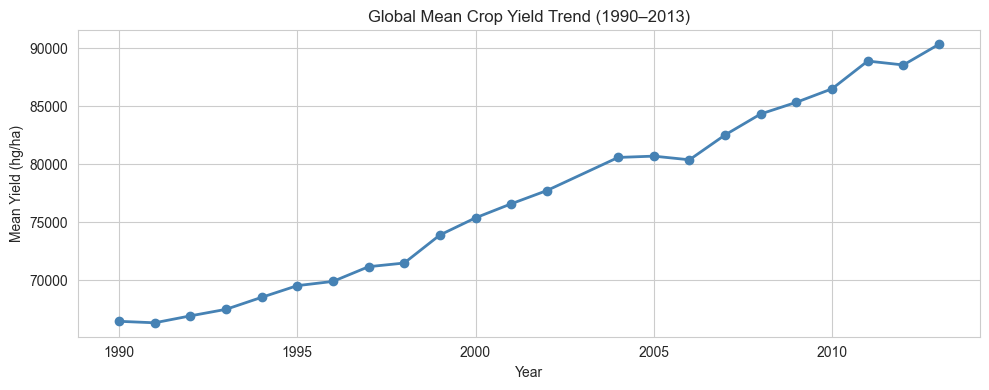

In [11]:
# Yield trend over years
yearly = df.groupby('Year')['hg/ha_yield'].mean().reset_index()
plt.figure(figsize=(10, 4))
plt.plot(yearly['Year'], yearly['hg/ha_yield'], marker='o', color='steelblue', linewidth=2)
plt.title('Global Mean Crop Yield Trend (1990–2013)')
plt.xlabel('Year')
plt.ylabel('Mean Yield (hg/ha)')
plt.tight_layout()
plt.show()

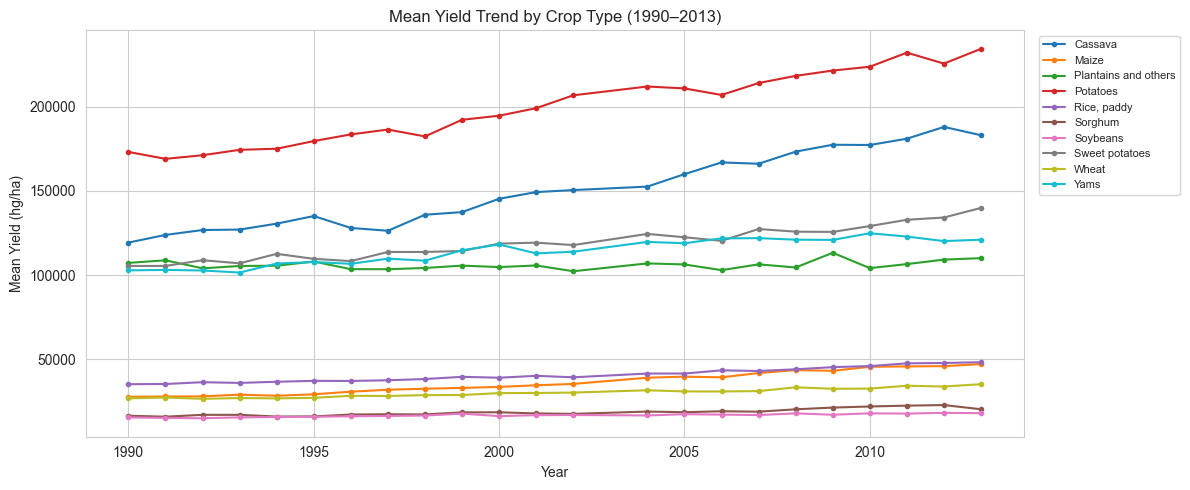

In [12]:
# Yield trend by crop type
pivot = df.groupby(['Year', 'Item'])['hg/ha_yield'].mean().unstack()
plt.figure(figsize=(12, 5))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], marker='o', markersize=3, linewidth=1.5, label=col)
plt.title('Mean Yield Trend by Crop Type (1990–2013)')
plt.xlabel('Year')
plt.ylabel('Mean Yield (hg/ha)')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [13]:
# Top country per crop
top_per_crop = df.groupby(['Item', 'Area'])['hg/ha_yield'].mean().reset_index()
top_per_crop = top_per_crop.loc[top_per_crop.groupby('Item')['hg/ha_yield'].idxmax()]
top_per_crop = top_per_crop.sort_values('hg/ha_yield', ascending=False).reset_index(drop=True)
print('Top country per crop (by mean yield):')
print(top_per_crop.to_string(index=False))

Top country per crop (by mean yield):
                Item      Area   hg/ha_yield
            Potatoes   Belgium 448891.538462
Plantains and others Guatemala 291096.304348
             Cassava     India 282234.434783
      Sweet potatoes     Egypt 261369.347826
                Yams     Japan 211343.434783
               Maize     Qatar 136593.000000
         Rice, paddy     Egypt  89234.695652
               Wheat   Belgium  84988.615385
             Sorghum   Austria  63873.250000
            Soybeans     Italy  34446.695652


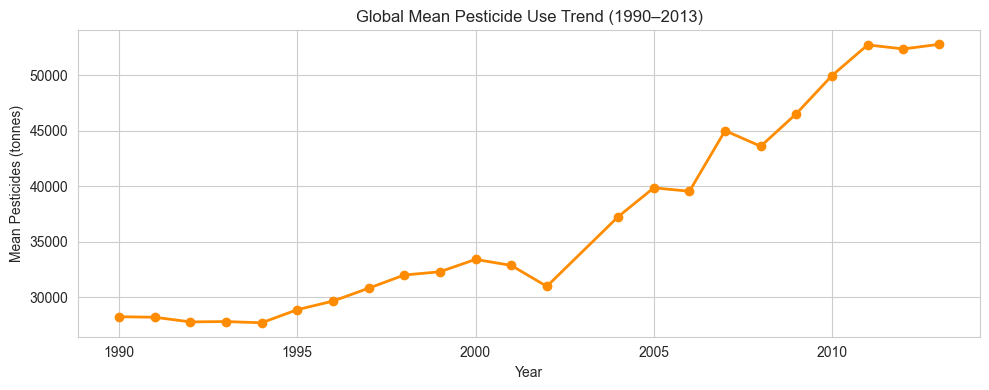

In [14]:
# Pesticide usage trend over years
pest_yearly = df.groupby('Year')['pesticides_tonnes'].mean()
plt.figure(figsize=(10, 4))
pest_yearly.plot(marker='o', color='darkorange', linewidth=2)
plt.title('Global Mean Pesticide Use Trend (1990–2013)')
plt.xlabel('Year')
plt.ylabel('Mean Pesticides (tonnes)')
plt.tight_layout()
plt.show()

## 8. Summary of Key Findings

The table below distills the most important observations from the EDA into a concise reference
for the cleaning and modelling steps that follow.

In [15]:
summary = pd.DataFrame({
    'Finding': [
        'Dataset size',
        'Target skewness',
        'No missing values',
        'No duplicate rows',
        'Highest-yield crop',
        'Lowest-yield crop',
        'Top-yield country',
        'Yield trend',
        'Pesticide trend',
        'Strongest numeric correlation',
    ],
    'Detail': [
        f"{df.shape[0]:,} rows × {df.shape[1]} columns, 101 countries, 10 crops, 1990–2013",
        f"Skew = {df['hg/ha_yield'].skew():.2f} — right-skewed; log-transform could help",
        'No nulls in any column',
        'No exact duplicate rows',
        f"{df.groupby('Item')['hg/ha_yield'].mean().idxmax()} ({df.groupby('Item')['hg/ha_yield'].mean().max():,.0f} hg/ha)",
        f"{df.groupby('Item')['hg/ha_yield'].mean().idxmin()} ({df.groupby('Item')['hg/ha_yield'].mean().min():,.0f} hg/ha)",
        f"{df.groupby('Area')['hg/ha_yield'].mean().idxmax()}",
        'Steady upward trend from 1990 to 2013',
        'Strong upward trend, especially after 2000',
        f"avg_temp (r = {df['hg/ha_yield'].corr(df['avg_temp']):.2f}), but crop type dominates",
    ]
})
summary

,Finding,Detail
0,Dataset size,"28,242 rows × 7 columns, 101 countries, 10 cro..."
1,Target skewness,Skew = 1.79 — right-skewed; log-transform coul...
2,No missing values,No nulls in any column
3,No duplicate rows,No exact duplicate rows
4,Highest-yield crop,"Potatoes (199,802 hg/ha)"
5,Lowest-yield crop,"Soybeans (16,731 hg/ha)"
6,Top-yield country,United Kingdom
7,Yield trend,Steady upward trend from 1990 to 2013
8,Pesticide trend,"Strong upward trend, especially after 2000"
9,Strongest numeric correlation,"avg_temp (r = -0.11), but crop type dominates"
